In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import sys
sys.path.append('/home/jovyan/work/base_demo')
import base_tool

In [12]:
import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

数据介绍

bid_book_begin 集合竞价后的完整委托买入订单簿

ask_book_begin 集合竞价后的完整委托卖出订单簿

snap_list 连续竞价阶段的1s快照
    time_hms  时分秒字符串
    time_mark 毫秒级时间戳
    price_open 快照内首个成交价(无成交时为0.0)
    price_low  快照内最低成交价(无成交时为0.0)
    price_high 快照内最高成交价(无成交时为0.0)
    price_last 当日内最新成交价
     buy_trade 主动买入成交
    sell_trade 主动卖出成交
    bid_insert 委托买入挂单
    ask_insert 委托卖出挂单
    bid_cancel 委托买入撤单
    ask_cancel 委托卖出撤单

In [13]:
param_dict = {
    'short_window' : 40 ,
    'long_window' : 120 , 
    'threshold' : 0.001 ,
    'name' : 'simple_MA'
}

In [14]:
%%time
from collections import deque
import logging
import os

class StrategyDemo():
    def __init__(self, param_dict={}) -> None:
        # self.model = joblib.load(file)
        self.name = param_dict.get('name')
        data_file = f'/home/jovyan/work/backtest_result/511520_20260319_{self.name}.pkl' 
        os.remove(data_file)

        self.position_last = 0

        self.short_window = param_dict.get('short_window')
        self.long_window = param_dict.get('long_window')
        self.threshold = param_dict.get('threshold',0.0)


        logging.basicConfig(
            level=logging.INFO,
            format='%(asctime)s - %(levelname)s - %(message)s',
        )
        self.logger = logging.getLogger(__name__)
        self.logger.info(f"策略初始化 - 短周期: {param_dict.get('short_window')}, 长周期: {param_dict.get('long_window')}, 阈值: {param_dict.get('threshold')}")

        self.price_list = deque(maxlen=self.long_window)
        self.prev_signal = 0

        return

    def on_snap(self, snap:dict) -> None:
        price = snap['price_last']

        if price == 0.0 or price == None:
            return

        self.price_list.append(price)

        if(len(self.price_list) < self.long_window):
            self.position_last = 0
            self.prev_signal = 0
            return

        short_ma = sum(list(self.price_list)[-self.short_window:]) / self.short_window
        long_ma = sum(self.price_list) / self.long_window
        diff = short_ma - long_ma

        if diff > self.threshold:
            current_signal = 1
        elif diff < -self.threshold:
            current_signal = -1
        else :
            current_signal = 0

        if current_signal != self.prev_signal:
            self.position_last = current_signal
            self.prev_signal = current_signal

            if current_signal == 1:
                self.logger.info(f"【买入信号】价格: {price}, 短均线: {short_ma:.4f}, 长均线: {long_ma:.4f}, 差值: {diff:.4f}")
            elif current_signal == -1:
                self.logger.info(f"【卖出信号】价格: {price}, 短均线: {short_ma:.4f}, 长均线: {long_ma:.4f}, 差值: {diff:.4f}")
            else:
                self.logger.info(f"【平仓/中性】价格: {price}, 均线回归中性区域")

        return

    

CPU times: user 14 μs, sys: 2 μs, total: 16 μs
Wall time: 17.4 μs


In [15]:
%%time
def backtest_demo(instrument_id, trade_ymd, strategy_name):
    strategy = StrategyDemo(param_dict)
    snap_list = base_tool.snap_list_load(instrument_id, trade_ymd)
    position_dict = {}
    for snap in snap_list[:]:
        strategy.on_snap(snap)
        position_dict[snap['time_mark']] = strategy.position_last
    profit = base_tool.backtest_quick(instrument_id, trade_ymd, strategy_name, position_dict)
    return profit
backtest_demo('511520', '20260319', 'simple_MA')



2026-03-27 07:21:18,625 - INFO - 策略初始化 - 短周期: 40, 长周期: 120, 阈值: 0.001
2026-03-27 07:21:18,704 - INFO - 【买入信号】价格: 116.015, 短均线: 116.0139, 长均线: 116.0102, 差值: 0.0037
2026-03-27 07:21:18,704 - INFO - 【平仓/中性】价格: 116.026, 均线回归中性区域
2026-03-27 07:21:18,705 - INFO - 【买入信号】价格: 116.029, 短均线: 116.0260, 长均线: 116.0249, 差值: 0.0011
2026-03-27 07:21:18,705 - INFO - 【平仓/中性】价格: 116.038, 均线回归中性区域
2026-03-27 07:21:18,706 - INFO - 【买入信号】价格: 116.042, 短均线: 116.0403, 长均线: 116.0392, 差值: 0.0010
2026-03-27 07:21:18,706 - INFO - 【平仓/中性】价格: 116.048, 均线回归中性区域
2026-03-27 07:21:18,706 - INFO - 【买入信号】价格: 116.053, 短均线: 116.0510, 长均线: 116.0500, 差值: 0.0010
2026-03-27 07:21:18,707 - INFO - 【平仓/中性】价格: 116.072, 均线回归中性区域
2026-03-27 07:21:18,707 - INFO - 【买入信号】价格: 116.076, 短均线: 116.0740, 长均线: 116.0730, 差值: 0.0010
2026-03-27 07:21:18,708 - INFO - 【平仓/中性】价格: 116.072, 均线回归中性区域
2026-03-27 07:21:18,708 - INFO - 【卖出信号】价格: 116.073, 短均线: 116.0735, 长均线: 116.0745, 差值: -0.0010
2026-03-27 07:21:18,708 - INFO - 【平仓/中性】价格: 116.075, 均线回归中性区域

/home/jovyan/work/backtest_result/511520_20260319_simple_MA.pkl Please wait
CPU times: user 143 ms, sys: 31 ms, total: 174 ms
Wall time: 465 ms


,order_time,order_price,total,trade,cancel,hold,profit_last,profits,maxdd,MAR,pper
0,2026-03-19 09:35:00,116.034,1,1,0,100,0.0,0.0,1.0,0.00,0.00
1,2026-03-19 09:36:51,116.038,2,2,0,0,0.4,0.4,1.0,0.40,0.20
2,2026-03-19 09:37:33,116.043,3,3,0,100,0.0,0.4,1.0,0.40,0.13
3,2026-03-19 09:40:37,116.047,4,4,0,0,0.4,0.8,1.0,0.80,0.20
4,2026-03-19 09:41:18,116.055,5,5,0,100,0.0,0.8,1.0,0.80,0.16
...,...,...,...,...,...,...,...,...,...,...,...
197,2026-03-19 14:52:30,116.170,203,198,5,0,-0.5,-7.7,13.3,-0.58,-0.04
198,2026-03-19 14:52:32,116.165,204,199,5,-100,0.0,-7.7,13.3,-0.58,-0.04
199,2026-03-19 14:53:27,116.170,205,200,5,0,-0.5,-8.2,13.6,-0.60,-0.04
200,2026-03-19 14:53:54,116.172,206,201,5,100,0.0,-8.2,13.6,-0.60,-0.04


In [16]:
import os
import sys
current_notebook_path = os.path.abspath('%pwd') 
current_dir = os.path.dirname(current_notebook_path)
parent_dir = os.path.dirname(current_dir)
utils_path = os.path.join(parent_dir, 'tools')
sys.path.append(utils_path)

Total 50 K-lines with freq=5min


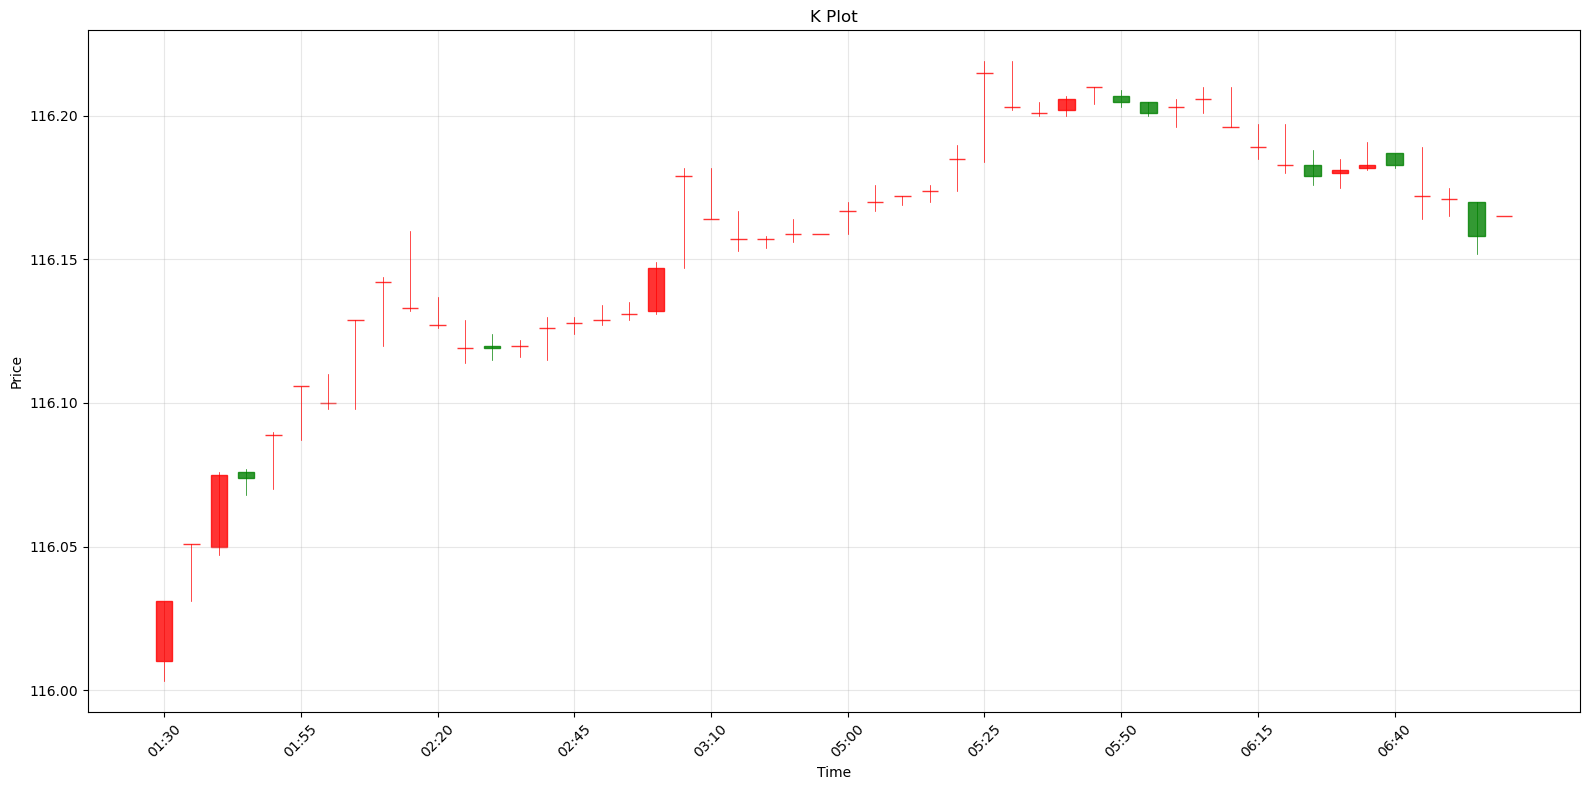

,datetime,open,high,low,close,idx
0,2026-03-19 01:30:00,116.010,116.031,116.003,116.031,0
1,2026-03-19 01:35:00,116.051,116.051,116.031,116.051,1
2,2026-03-19 01:40:00,116.050,116.076,116.047,116.075,2
3,2026-03-19 01:45:00,116.076,116.077,116.068,116.074,3
4,2026-03-19 01:50:00,116.089,116.090,116.070,116.089,4
...,...,...,...,...,...,...
45,2026-03-19 06:40:00,116.187,116.187,116.182,116.183,45
46,2026-03-19 06:45:00,116.172,116.189,116.164,116.172,46
47,2026-03-19 06:50:00,116.171,116.175,116.165,116.171,47
48,2026-03-19 06:55:00,116.170,116.170,116.152,116.158,48


In [ ]:
from Kline import plot_kline

snap_list = base_tool.snap_list_load('511520', '20260319')
plot_kline(snap_list,freq='5min')